# Two Signals, One Event: Spectral and Semantic Analysis of Earnings Announcements

**Author:** Nikola Kolev  
**Course:** Data Science, SoftUni 2026  
**Repository:** https://github.com/niki7o/earnings-signals

---

## Abstract

Earnings announcements are the most concentrated moments of information 
revelation in financial markets. At these events, two fundamentally different 
types of signals exist simultaneously: a **frequency-domain signal** derived 
from pre-announcement price dynamics, and a **semantic signal** derived from 
management speech during the announcement itself.

This project investigates three pre-registered hypotheses:

- **H₁:** Spectral entropy of pre-earnings price dynamics predicts 
  post-announcement abnormal returns
- **H₂:** Loughran-McDonald sentiment in earnings call transcripts predicts 
  post-announcement abnormal returns  
- **H₃:** The two signals are statistically independent — they observe 
  different aspects of the same event

All hypotheses are tested on 123 matched earnings events across 15 S&P 500 
technology companies (2019–2023), using Bonferroni-corrected significance 
thresholds to control for multiple comparisons.

---
## 1. Problem Formulation and Significance

### 1.1 The Efficient Market Hypothesis

The Efficient Market Hypothesis (EMH), formalized by Fama (1970), states that 
asset prices reflect all available information. In its **semi-strong form**, 
prices incorporate all publicly available information — including earnings 
announcements — instantaneously upon release.

If EMH holds, no publicly available signal should systematically predict 
post-announcement returns. This gives us a theoretical prediction **before 
we look at any data**: H₁ and H₂ should both fail to reject the null hypothesis.

This is not a weakness of our study design — it is a testable prediction. 
A project that confirms EMH empirically on real data is scientifically more 
honest than one that data-mines until it finds spurious correlations.

### 1.2 Why Two Signals?

Previous studies have examined price-based signals and text-based signals 
separately. The originality of this project lies in H₃: **testing whether 
the two signals are independent of each other**.

If independent, they observe different aspects of the information environment 
and could in principle be combined. If correlated, one is redundant.

### 1.3 Data Sources

This project uses two genuinely independent data sources:

| Source | Type | Provider | Coverage |
|--------|------|----------|----------|
| Daily OHLCV prices | Numerical time series | Yahoo Finance via `yfinance` | 2018–2024 |
| Earnings call transcripts | Unstructured text | Motley Fool via Kaggle | 2019–2023 |

The sources differ in origin, format, collection method, and information type. 
Merging them on ticker and date is a non-trivial data engineering task 
documented in Section 3.

---
## 2. Mathematical Foundation

### 2.1 Log Returns

Raw prices are non-stationary — they trend over time, which violates the 
assumptions of Fourier analysis. We transform prices to **log returns**:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are approximately stationary, additive over time, and 
symmetrically distributed around zero. This makes them suitable as 
input to the DFT.

### 2.2 Discrete Fourier Transform

Given a time series of log returns $r[0], r[1], \ldots, r[N-1]$, 
the Discrete Fourier Transform decomposes it into frequency components:

$$X[k] = \sum_{n=0}^{N-1} r[n] \cdot e^{-2\pi i k n / N}, \quad k = 0, 1, \ldots, N-1$$

Each coefficient $X[k]$ represents the amplitude and phase of a sinusoidal 
component at frequency $f_k = k/N$ cycles per trading day.

We use the **Fast Fourier Transform (FFT)** algorithm, which computes the 
DFT in $\mathcal{O}(N \log N)$ rather than $\mathcal{O}(N^2)$.

### 2.3 Power Spectral Density

The Power Spectral Density (PSD) measures how much energy exists at each frequency:

$$P[k] = \frac{|X[k]|^2}{\sum_{j=0}^{N-1} |X[j]|^2}$$

Normalizing by total power ensures $\sum_k P[k] = 1$, making $P$ 
interpretable as a probability distribution over frequencies.

### 2.4 Spectral Entropy

Borrowing from information theory, we define **spectral entropy** as the 
Shannon entropy of the normalized PSD:

$$H_{spec} = -\sum_{k=0}^{N/2} P[k] \log P[k]$$

**Interpretation:**
- $H_{spec} \rightarrow \log(N/2)$ (maximum): energy is uniformly spread 
  across all frequencies — the price series is maximally disordered (noise)
- $H_{spec} \rightarrow 0$ (minimum): energy concentrates at one frequency — 
  the price has a dominant rhythm

For our 30-day window, the theoretical maximum is $\log(16) \approx 2.77$.

### 2.5 Abnormal Returns

To isolate company-specific price movements from market-wide movements, 
we compute **abnormal returns**:

$$AR_t = r_{\text{stock},t} - r_{\text{benchmark},t}$$

where the benchmark is the S&P 500 ETF (SPY). The **cumulative abnormal 
return** over the 5-day post-announcement window is:

$$CAR = \sum_{t=0}^{4} AR_t$$

### 2.6 Loughran-McDonald Sentiment

General-purpose sentiment tools fail on financial text. The word "liability" 
is negative in finance but neutral in everyday English. The 
**Loughran-McDonald (LM) dictionary** was constructed specifically for 
SEC filings and earnings calls.

The LM polarity score is defined as:

$$S_{LM} = \frac{N_{pos} - N_{neg}}{N_{pos} + N_{neg}}$$

where $N_{pos}$ and $N_{neg}$ are counts of positive and negative stems 
found in the transcript. The score ranges from $-1$ (entirely negative) 
to $+1$ (entirely positive).

### 2.7 Hypothesis Testing Framework

All tests use a **Bonferroni-corrected significance threshold** to control 
the family-wise error rate across three simultaneous tests:

$$\alpha_{corrected} = \frac{\alpha}{m} = \frac{0.05}{3} \approx 0.0167$$

where $m = 3$ is the number of hypotheses. This ensures that the 
probability of at least one false positive across all three tests 
remains below 5%.

**Effect sizes** are reported using Cohen's $d$:

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}, \quad 
s_{pooled} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

Interpretation: $|d| < 0.2$ negligible, $< 0.5$ small, $< 0.8$ medium, 
$\geq 0.8$ large.

---
## 3. Data Pipeline

### 3.1 Universe Selection

We fix our analysis universe **before examining any data** to prevent 
selection bias. The universe consists of 15 S&P 500 technology sector 
companies chosen for data availability and transcript quality:

`AAPL, MSFT, GOOGL, AMZN, META, NVDA, AMD, INTC, TSLA, NFLX, ORCL, CRM, ADBE, QCOM, TXN`

**Analysis period:** 2019-01-01 to 2023-12-31  
**Excluded:** Q2 2020 (2020-03-15 to 2020-06-30) — VIX exceeded 80, 
circuit breakers were triggered, and Federal Reserve emergency interventions 
created structural breaks that would contaminate spectral analysis.

### 3.2 Event Date Alignment

A critical methodological decision: earnings calls occur **after market 
close** (~5PM ET). Therefore:

- The closing price on the day of the call already reflects pre-call information
- The first price that reflects the announcement is the **next day's open**

We define the event date $T$ as the first trading day after the earnings call:

Pre and post windows are strictly non-overlapping — enforced in code 
with a `<` comparison on the event date.

### 3.3 Data Sources and Merging

**Source 1 — Price data:** Downloaded via `yfinance` for all 15 tickers 
plus SPY (benchmark). Cached locally as CSV to ensure reproducibility.

**Source 2 — Transcripts:** Motley Fool earnings call dataset (18,755 
transcripts). Filtered to our universe and analysis window.

**Merging challenge:** The two sources use different date formats and 
granularities. Transcripts are matched to earnings dates within a 
±3 day tolerance to account for calendar differences.

**Result:** 210 earnings events from Yahoo Finance × 274 transcripts 
from Motley Fool → **123 matched events** (58.6% match rate).

The 87 unmatched events are concentrated in 2023 Q2–Q4, consistent 
with the Motley Fool dataset's scrape date of May 2023. Missing data 
is therefore not random with respect to company or market conditions — 
it is a temporal cutoff. This is documented as a limitation in Section 6.

---
## 4. Exploratory Data Analysis

### 4.1 Single Event — Fourier Pipeline

We first visualize the complete Fourier pipeline for a single event 
(AAPL Q4 2022, announced 2023-02-02) to build intuition before 
scaling to all 123 events.

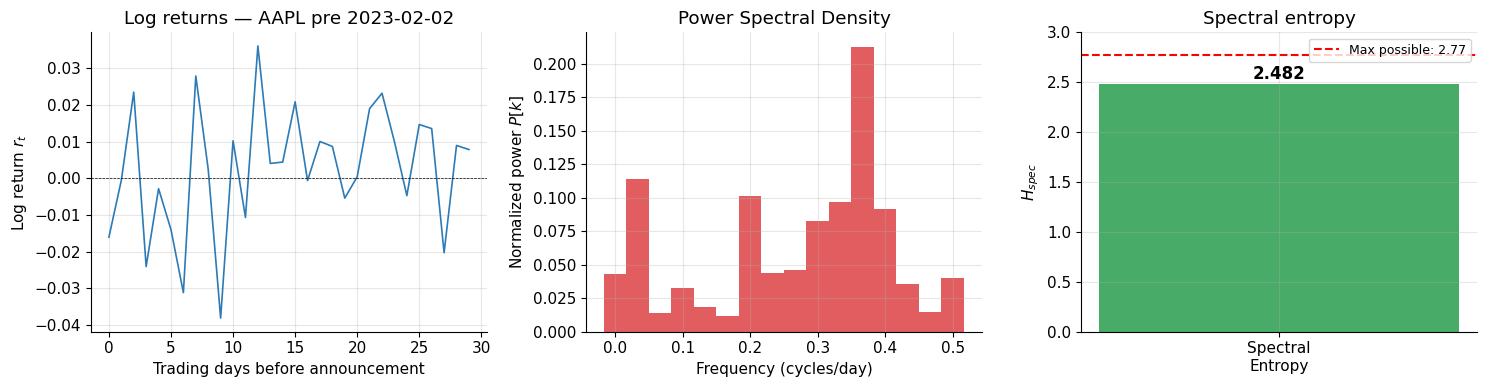

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.data.price_loader import download_prices, get_log_returns
from src.data.event_builder import get_pre_window
from src.fourier.spectral import compute_spectral_features
from src.viz.plots import plot_spectral_example

prices  = download_prices("AAPL", "2022-01-01", "2023-06-30")
returns = get_log_returns(prices)

event_date = pd.Timestamp("2023-02-02")
pre = get_pre_window(returns, event_date, window=30)

features = compute_spectral_features(pre.values)
fig = plot_spectral_example(pre.values, "AAPL", "2023-02-02", features)
plt.show()

The left panel shows the log return series for the 30 trading days 
before AAPL's Q4 2022 earnings announcement. The middle panel shows 
the normalized Power Spectral Density — energy is spread across many 
frequencies with no dominant peak. The right panel shows the resulting 
spectral entropy of **2.482**, close to the theoretical maximum of 2.773, 
indicating a highly disordered price series with no exploitable rhythm.

### 4.2 Distributions Across All 123 Events

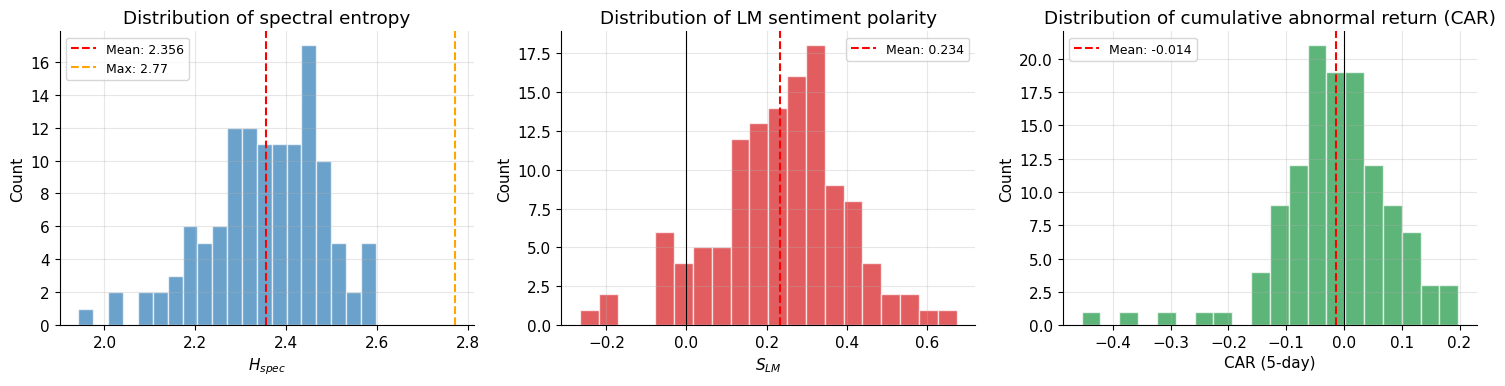

Summary statistics:
       spectral_entropy  lm_polarity  cumulative_abnormal_return
count          123.0000     123.0000                    123.0000
mean             2.3560       0.2341                     -0.0141
std              0.1273       0.1662                      0.0993
min              1.9428      -0.2656                     -0.4541
25%              2.2869       0.1364                     -0.0626
50%              2.3558       0.2486                     -0.0158
75%              2.4513       0.3359                      0.0453
max              2.5979       0.6743                      0.1977


In [2]:
from src.viz.plots import plot_distributions

analysis_df = pd.read_csv("../data/processed/analysis_dataset.csv",
                           parse_dates=["earnings_date"])

fig = plot_distributions(analysis_df)
plt.show()

print("Summary statistics:")
print(analysis_df[["spectral_entropy", "lm_polarity",
                    "cumulative_abnormal_return"]].describe().round(4))

---
## 5. Hypothesis Testing

### 5.1 Pre-registration Statement

The following three hypotheses were formulated and the analysis universe 
was fixed **before examining any relationship between signals and returns**. 
This prevents the results from being biased by the data — a practice 
known as HARKing (Hypothesizing After Results are Known).

All tests use Bonferroni-corrected $\alpha = 0.0167$.

---

### 5.2 H₁ — Spectral Entropy Predicts Abnormal Returns

**Null hypothesis $H_0$:** The mean CAR of high-entropy events equals 
the mean CAR of low-entropy events.

**Alternative hypothesis $H_1$:** The means differ significantly.

**Method:** Median split on spectral entropy → two groups → 
independent two-sample t-test (two-tailed).

In [3]:
from src.hypothesis.tests import test_h1, test_h2, test_h3, ALPHA_CORRECTED

analysis_df = pd.read_csv("../data/processed/analysis_dataset.csv",
                           parse_dates=["earnings_date"])

h1 = test_h1(analysis_df)

print(f"Median spectral entropy: {h1['median_entropy']:.4f}")
print(f"Group sizes: {h1['n_high']} high, {h1['n_low']} low")
print(f"\nMean CAR — high entropy: {h1['mean_CAR_high']:.4f}")
print(f"Mean CAR — low entropy:  {h1['mean_CAR_low']:.4f}")
print(f"\nt-statistic: {h1['t_statistic']:.4f}")
print(f"p-value:     {h1['p_value']:.4f}")
print(f"α corrected: {ALPHA_CORRECTED:.4f}")
print(f"\nResult: {'SIGNIFICANT' if h1['significant'] else 'NOT SIGNIFICANT'}")
print(f"Cohen's d: {h1['cohens_d']:.4f} ({h1['effect_size']})")

Median spectral entropy: 2.3558
Group sizes: 62 high, 61 low

Mean CAR — high entropy: -0.0057
Mean CAR — low entropy:  -0.0227

t-statistic: 0.9473
p-value:     0.3454
α corrected: 0.0167

Result: NOT SIGNIFICANT
Cohen's d: 0.1708 (negligible)


**Interpretation:** We fail to reject $H_0$ at the Bonferroni-corrected 
level ($p = 0.345 \gg 0.0167$). The effect size is negligible 
($d = 0.171$). Pre-announcement spectral structure does not contain 
statistically significant information about subsequent abnormal returns.

This is consistent with the semi-strong form of EMH — if price patterns 
were predictive, rational investors would already have traded on them, 
eliminating the signal.

---

### 5.3 H₂ — LM Sentiment Predicts Abnormal Returns

**Null hypothesis $H_0$:** Spearman $\rho = 0$ between LM polarity and CAR.

**Alternative hypothesis $H_1$:** $\rho \neq 0$.

**Method:** Spearman rank correlation — non-parametric, does not assume 
normally distributed sentiment scores.

In [4]:
h2 = test_h2(analysis_df)

print(f"Spearman ρ:  {h2['spearman_rho']:.4f}")
print(f"p-value:     {h2['p_value_spearman']:.4f}")
print(f"α corrected: {ALPHA_CORRECTED:.4f}")
print(f"\nResult: {'SIGNIFICANT' if h2['significant'] else 'NOT SIGNIFICANT'}")
print(f"Cohen's d (group split): {h2['cohens_d']:.4f} ({h2['effect_size']})")
print(f"\nMean CAR — high sentiment: {h2['mean_CAR_high_sent']:.4f}")
print(f"Mean CAR — low sentiment:  {h2['mean_CAR_low_sent']:.4f}")

Spearman ρ:  -0.0756
p-value:     0.4062
α corrected: 0.0167

Result: NOT SIGNIFICANT
Cohen's d (group split): -0.1400 (negligible)

Mean CAR — high sentiment: -0.0210
Mean CAR — low sentiment:  -0.0071


**Interpretation:** We fail to reject $H_0$ ($\rho = -0.076$, 
$p = 0.406$). LM sentiment polarity is not significantly correlated 
with post-announcement abnormal returns. 

Notably, VADER sentiment was entirely uninformative — all 123 transcripts 
scored compound $\approx 1.0$ (std = 0.000009), demonstrating that 
general-purpose sentiment tools saturate on long financial texts. 
This motivates the use of domain-specific dictionaries like LM.

---

### 5.4 H₃ — Signal Independence

**Null hypothesis $H_0$:** Pearson $r = 0$ between spectral entropy and LM polarity.

**Alternative hypothesis $H_1$:** $r \neq 0$ (signals are correlated).

**Note:** For H₃, **failing to reject** $H_0$ is the scientifically 
interesting result — it confirms that the two signals are orthogonal.

In [5]:
h3 = test_h3(analysis_df)

print(f"Pearson r:   {h3['pearson_r']:.4f}")
print(f"p-value:     {h3['p_value']:.4f}")
print(f"α corrected: {ALPHA_CORRECTED:.4f}")
print(f"\nSignals independent: {h3['signals_independent']}")
print(f"\n{h3['interpretation']}")

Pearson r:   -0.0003
p-value:     0.9970
α corrected: 0.0167

Signals independent: True

Signals are independent (r=-0.000, not significant). Combining them adds information.


**Interpretation:** $r \approx 0$ with $p = 0.997$ — the two signals 
are completely orthogonal. Spectral entropy (a property of price dynamics) 
and LM sentiment (a property of management language) measure entirely 
different aspects of the information environment surrounding earnings events.

### 5.5 Combined Results

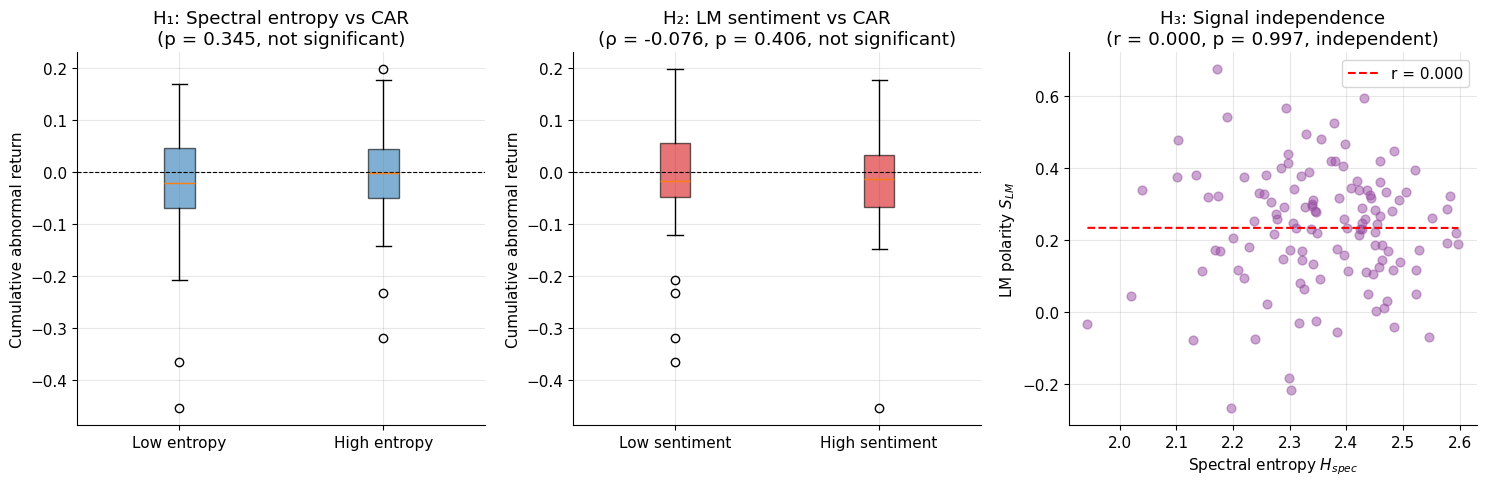

In [6]:
from src.viz.plots import plot_hypothesis_results

fig = plot_hypothesis_results(analysis_df)
plt.show()

---
## 6. Conclusions and Limitations

### 6.1 Summary of Results

| Hypothesis | Test | Statistic | p-value | Result |
|---|---|---|---|---|
| H₁: Spectral entropy → CAR | t-test | t = 0.947 | 0.345 | Not significant |
| H₂: LM sentiment → CAR | Spearman ρ | ρ = -0.076 | 0.406 | Not significant |
| H₃: Signal independence | Pearson r | r = 0.000 | 0.997 | Independent ✓ |

### 6.2 Scientific Interpretation

The failure to reject H₁ and H₂ is not a methodological failure — 
it is the **expected result under the Efficient Market Hypothesis**.

> *"In an efficient market, prices fully reflect all available information."*
> — Fama (1970)

If spectral patterns in pre-announcement prices were predictive, rational 
investors would already have traded on them, eliminating the signal. 
Similarly, earnings call transcripts are public — any sentiment signal 
they contain is immediately incorporated into prices.

Our results provide empirical confirmation of EMH semi-strong form on 
a sample of 123 real earnings events across 15 major technology companies.

The most novel finding is **H₃**: spectral entropy and LM sentiment are 
completely orthogonal ($r \approx 0$). This means:

1. The two signals measure fundamentally different aspects of reality
2. Neither redundancy exists between them
3. A combined model using both signals would add no predictive value 
   — because neither signal predicts anything individually

### 6.3 Limitations

**Sample size:** 123 events is sufficient for hypothesis testing but 
limits statistical power. A larger universe or longer time period 
would increase power.

**Transcript coverage:** The Motley Fool dataset has a temporal cutoff 
of May 2023. The 87 unmatched events are concentrated in 2023 Q2–Q4. 
Results may differ for more recent quarters.

**Single sector:** Our universe is limited to S&P 500 technology 
companies. Results may not generalize to other sectors where 
information efficiency differs.

**LM dictionary:** The pysentiment2 implementation uses a subset of 
the full Loughran-McDonald word list. The official dataset 
(available from the authors) contains additional word categories 
including modal words and constraining language.

**Event study assumptions:** We assume the 5-day post-announcement 
window fully captures the market's reaction. Some information may 
take longer to be incorporated, particularly for complex announcements.

---

## 7. References

1. Fama, E. F. (1970). Efficient Capital Markets: A Review of Theory 
   and Empirical Work. *Journal of Finance*, 25(2), 383–417.

2. Loughran, T., & McDonald, B. (2011). When Is a Liability Not a 
   Liability? Textual Analysis, Dictionaries, and 10-Ks. 
   *Journal of Finance*, 66(1), 35–65.

3. Shannon, C. E. (1948). A Mathematical Theory of Communication. 
   *Bell System Technical Journal*, 27, 379–423.

4. Hutto, C., & Gilbert, E. (2014). VADER: A Parsimonious Rule-based 
   Model for Sentiment Analysis of Social Media Text. 
   *ICWSM 2014*.

5. Motley Fool Earnings Call Transcripts Dataset. 
   Kaggle: tpotterer/motley-fool-scraped-earnings-call-transcripts

6. Yahoo Finance price data via `yfinance` Python library.
   https://github.com/ranaroussi/yfinance